### **1.Consumo di alcol per paese** 
Esegui un’**analisi esplorativa** focalizzata sul **consumo di alcol**.  
Analizza i seguenti aspetti:
* Visualizza i primi 10 paesi ordinati per total_litres_of_pure_alcohol (dal più alto)

* Calcola la media del consumo di birra, vino, e distillati

* Crea una nuova colonna alcohol_index che sia: `(beer_servings + wine_servings + spirit_servings) / 3`

* Trova il paese con il valore massimo di alcohol_index

* Filtra solo i paesi che consumano più di 100 birre all’anno

Crea un bar chart dei 10 paesi con più consumo totale (total_litres_of_pure_alcohol)

Crea un line plot con wine_servings ordinato per paese (usa sort_values)

                country  beer_servings  spirit_servings  wine_servings  \
15              Belarus            142              373             42   
98            Lithuania            343              244             56   
3               Andorra            245              138            312   
68              Grenada            199              438             28   
61               France            127              151            370   
45       Czech Republic            361              170            134   
141  Russian Federation            247              326             73   
99           Luxembourg            236              133            271   
155            Slovakia            196              293            116   
81              Ireland            313              118            165   

     total_litres_of_pure_alcohol  
15                           14.4  
98                           12.9  
3                            12.4  
68                           11.9  
61   

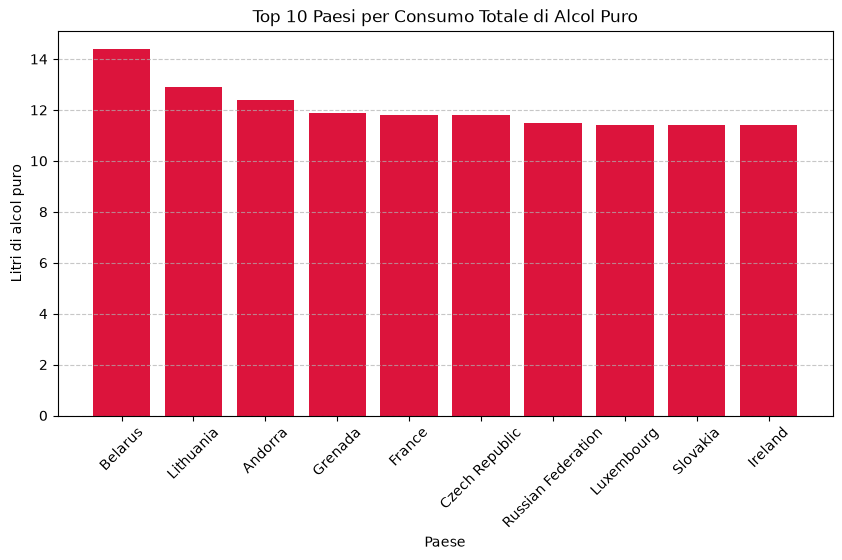

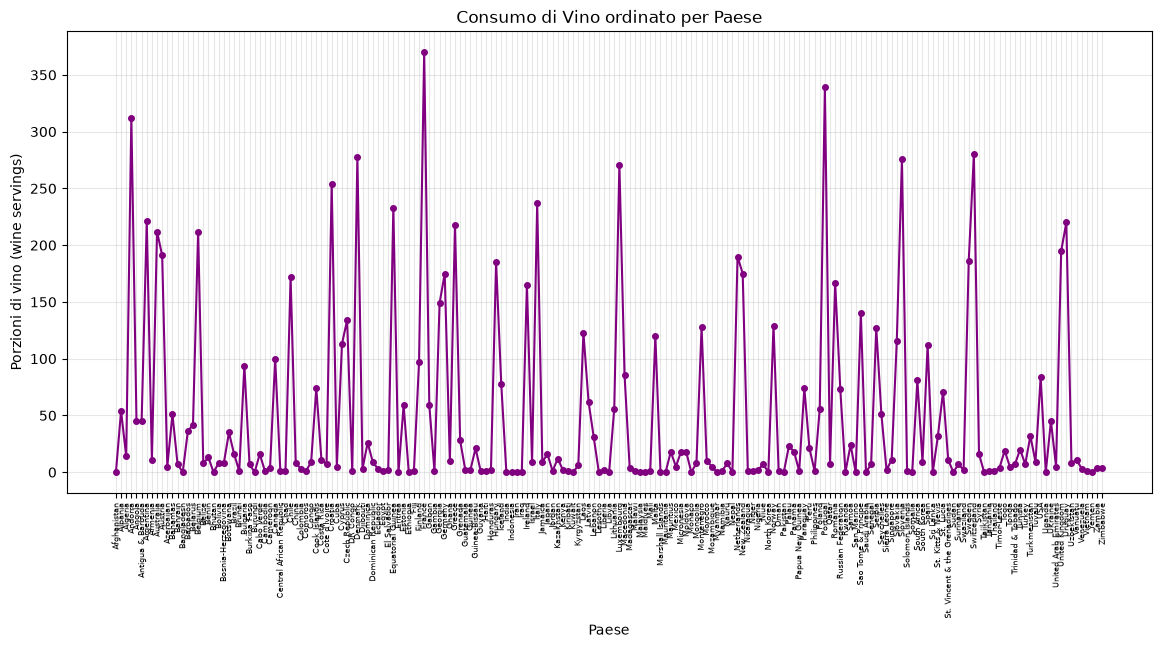

In [32]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")

top_10_alcohol = df.sort_values(by='total_litres_of_pure_alcohol', ascending=False).head(10)
print(top_10_alcohol)

media_consumi = df[['beer_servings', 'wine_servings', 'spirit_servings']].mean()
print(media_consumi)

df['alcohol_index'] = (df['beer_servings'] + df['wine_servings'] + df['spirit_servings']) / 3

paese_max_index = df.loc[df['alcohol_index'].idxmax()]
print(paese_max_index)

paesi_molta_birra = df[df['beer_servings'] > 100]
paesi_molta_birra[['country', 'beer_servings']].head()

import matplotlib.pyplot as plt

top_10 = df.sort_values(by='total_litres_of_pure_alcohol', ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_10['country'], top_10['total_litres_of_pure_alcohol'], color='crimson')
plt.title('Top 10 Paesi per Consumo Totale di Alcol Puro')
plt.xlabel('Paese')
plt.ylabel('Litri di alcol puro')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

df_ordinato_paese = df.sort_values(by='country')

plt.figure(figsize=(14, 6))
plt.plot(df_ordinato_paese['country'], df_ordinato_paese['wine_servings'], marker='o', linestyle='-', color='purple', markersize=4)
plt.title('Consumo di Vino ordinato per Paese')
plt.xlabel('Paese')
plt.ylabel('Porzioni di vino (wine servings)')
plt.xticks(rotation=90, fontsize=6) 
plt.grid(True, alpha=0.3)
plt.show()

### **2.Analisi offerte di lavoro** 

Esegui un’**analisi esplorativa** focalizzata sui **lavori nel campo dei dati in ciascun paese**.  
Analizza i seguenti aspetti per ogni paese:

* Lo **stipendio medio annuale** (`salary_year_avg`)
* Il **numero totale di offerte di lavoro** (job count)
* L’intervallo degli stipendi: **valore minimo e massimo** (`min` / `max`)

Rappresenta graficamente lo stipendio medio (`salary_year_avg`) per `job_title_short` usando un grafico a barre orizzontali. Ordina i dati dallo stipendio più alto al più basso. Includi un titolo e le etichette per gli assi x e y.

Stipendio medio per paese:
job_country
Afghanistan              NaN
Albania         79472.500000
Algeria         44550.000000
Angola                   NaN
Argentina      105212.343750
                   ...      
Venezuela                NaN
Vietnam         90927.236364
Yemen                    NaN
Zambia          90670.000000
Zimbabwe        67056.666667
Name: salary_year_avg, Length: 160, dtype: float64

Numero totale di offerte per paese:
job_country
Afghanistan      16
Albania         119
Algeria         111
Angola           11
Argentina      8736
               ... 
Venezuela        69
Vietnam        2414
Yemen            10
Zambia          104
Zimbabwe         81
Length: 160, dtype: int64

Stipendio minimo e massimo per paese:
job_country
Afghanistan        NaN
Albania        43200.0
Algeria        44100.0
Angola             NaN
Argentina      45000.0
                ...   
Venezuela          NaN
Vietnam        28000.0
Yemen              NaN
Zambia         90670.0
Zimbabwe       

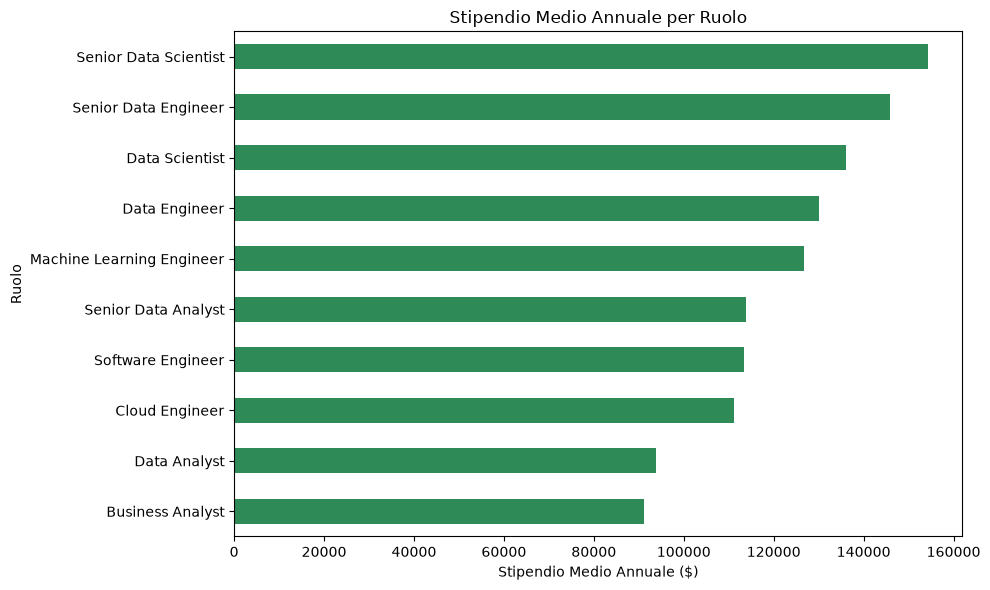

In [34]:
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])


print("Stipendio medio per paese:")
print(df.groupby('job_country')['salary_year_avg'].mean())

print("\nNumero totale di offerte per paese:")
print(df.groupby('job_country').size())

print("\nStipendio minimo e massimo per paese:")
print(df.groupby('job_country')['salary_year_avg'].min())
print(df.groupby('job_country')['salary_year_avg'].max())

media_per_ruolo = df.groupby('job_title_short')['salary_year_avg'].mean().sort_values()

plt.figure(figsize=(10, 6))
media_per_ruolo.plot(kind='barh', color='seagreen')
plt.title("Stipendio Medio Annuale per Ruolo")
plt.xlabel("Stipendio Medio Annuale ($)")
plt.ylabel("Ruolo")
plt.tight_layout()
plt.show()

### **3. Analisi vendite (dataset tips)**

Esegui un’**analisi esplorativa** focalizzata sulle **vendite giornaliere**.  
Analizza i seguenti aspetti per ogni giorno (`day`):

* Il **conto medio** (`total_bill`)
* Il **numero totale di osservazioni** (conteggio delle righe)
* Il **valore minimo e massimo** del conto (`total_bill` → `min` / `max`)

* Crea una nuova colonna `conto_per_persona` che sia:  
  `total_bill / size`

* Trova il giorno con il **conto medio più alto**

Rappresenta graficamente il **conto medio (`total_bill`) per giorno** usando un **grafico a barre**.  
Ordina i dati dal valore più alto al più basso.  
Aggiungi titolo ed etichette agli assi.

           mean  count   min    max
day                                
Sun   21.410000     76  7.25  48.17
Sat   20.441379     87  3.07  50.81
Thur  17.682742     62  7.51  43.11
Fri   17.151579     19  5.75  40.17

Il giorno con il conto medio più alto è: Sun


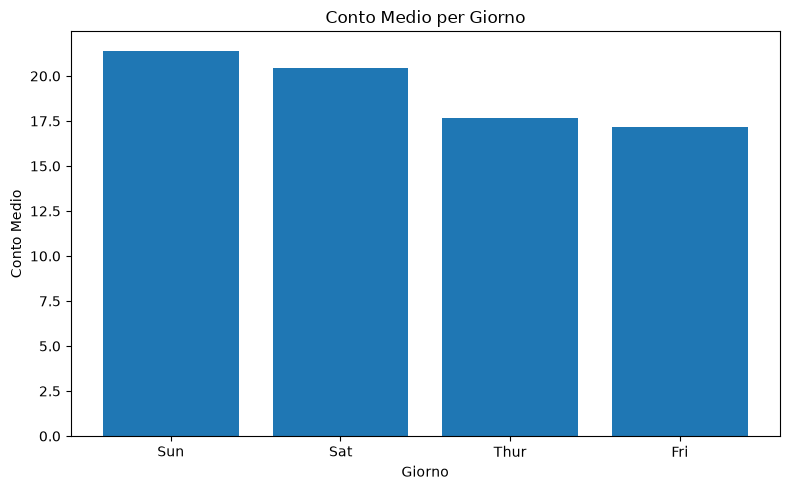

In [39]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

df["conto_per_persona"] = df["total_bill"] / df["size"]

analisi_giornaliera = df.groupby("day")["total_bill"].agg(["mean", "count", "min", "max"])
analisi_giornaliera = analisi_giornaliera.sort_values(by="mean", ascending=False)
print(analisi_giornaliera)

print("\nIl giorno con il conto medio più alto è:", analisi_giornaliera.index[0])

plt.figure(figsize=(8, 5))
plt.bar(analisi_giornaliera.index, analisi_giornaliera["mean"])
plt.title("Conto Medio per Giorno")
plt.xlabel("Giorno")
plt.ylabel("Conto Medio")
plt.tight_layout()
plt.show()